In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torchvision import io
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
stomach_data_and_masks_folder = os.listdir('/home/miguel/GI/0 - Data Exploration & Analysis/UW-Madison/stomach_data_and_masks_preparation/stomach_data_and_masks')

In [3]:
case_data = []

for image_filename in tqdm(stomach_data_and_masks_folder):
    if 'stomach_mask' not in image_filename:
        case_id = image_filename.split('_')[0]
        image_data = io.read_image(f'/home/miguel/GI/0 - Data Exploration & Analysis/UW-Madison/stomach_data_and_masks_preparation/stomach_data_and_masks/{image_filename}')
        case_data.append({
            'case_id': case_id,
            'image_filename': image_filename,
            'image_data_pixel_sum': int(image_data.flatten().sum()),
            'image_data_num_pixels': len(image_data.flatten()),
        })

100%|██████████| 17254/17254 [00:09<00:00, 1843.50it/s]


In [4]:
case_data_df = pd.DataFrame(case_data)

In [5]:
case_data_df['count'] = 1

In [6]:
grouped = (
    case_data_df
    .groupby("case_id", as_index=False)[
        ["image_data_pixel_sum", "image_data_num_pixels", 'count']
    ]
    .sum()
)


In [7]:
grouped['mean_pixel_value'] = grouped['image_data_pixel_sum'] / grouped['image_data_num_pixels']

<Axes: >

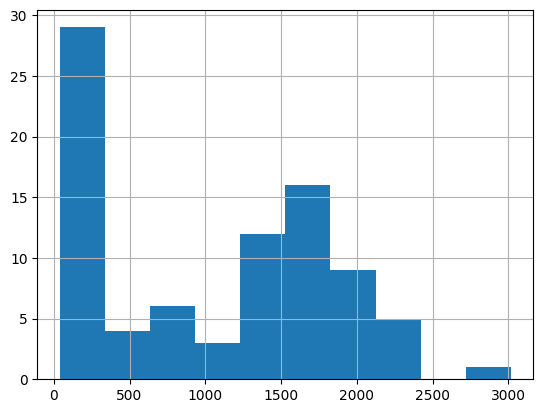

In [8]:
grouped['mean_pixel_value'].hist()

In [9]:
grouped['mean_pixel_value'].min()

np.float64(40.53248534624448)

In [10]:
grouped.to_csv('high_quality_subjects.csv')

In [11]:
grouped[grouped['case_id'] == 'case148']

,case_id,image_data_pixel_sum,image_data_num_pixels,count,mean_pixel_value
36,case148,316704839,4798800,43,65.996674


In [71]:

high_quality_subjects = pd.read_csv('high_quality_subjects.csv', index_col = 0)

In [74]:
high_quality_subjects.sample(10)

,case_id,image_data_pixel_sum,image_data_num_pixels,count,mean_pixel_value
61,case49,2587078523,9374400,84,275.972705
12,case118,9655909482,5050480,70,1911.879560
32,case144,7004704640,4386872,62,1596.742426
17,case124,10771296010,8207696,116,1312.341004
47,case24,11255331773,7500136,106,1500.683691
25,case136,9075637045,12316240,125,736.883744
75,case80,11019031062,8207696,116,1342.524268
31,case143,12532827023,9693572,137,1292.900803
49,case30,7854124752,5094432,72,1541.707643
64,case55,4637187060,7146356,101,648.888337


In [12]:
import os
from torchvision import io
from tqdm import tqdm

In [17]:
data = []
for folder in tqdm(os.listdir('train')):
    for subfolder in os.listdir(f'train/{folder}'):
        total_pixels = 0
        num_pixels = 0
        pixel_vars = []
        for file in os.listdir(f'train/{folder}/{subfolder}/scans/'):
            if file.endswith('.png'):
                image_path = f'train/{folder}/{subfolder}/scans/{file}'
                image_data = io.read_image(image_path)

                total_pixels += int(image_data.flatten().sum())
                num_pixels += len(image_data.flatten())

                pixel_vars.append(np.array(image_data.flatten()).var())
        mean_pixels =   total_pixels / num_pixels if num_pixels > 0 else 0  
        data.append({
            'case_id': subfolder,
            'mean_pixel_value': mean_pixels,
            'pixel_var': np.mean(pixel_vars) if pixel_vars else 0
        })

  0%|          | 0/85 [00:00<?, ?it/s]/tmp/ipykernel_327092/564202914.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pixel_vars.append(np.array(image_data.flatten()).var())
100%|██████████| 85/85 [00:48<00:00,  1.76it/s]


In [18]:
data = pd.DataFrame(data)

In [21]:
# high_quality_subjects = data[(data['mean_pixel_value'] > 200)]
high_quality_subjects = data

In [22]:
high_quality_subjects['case_number'] = [int(case[4:]) for case in high_quality_subjects['case_id'].str.split('_').str[0]]
high_quality_subjects['day_number'] = [int(day[3:]) for day in high_quality_subjects['case_id'].str.split('_').str[1]]

In [23]:
high_quality_subjects.sort_values(by=['case_number', 'day_number'], inplace=True)

In [24]:
from matplotlib import pyplot as plt

Error in callback <function _draw_all_if_interactive at 0x7992136998a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

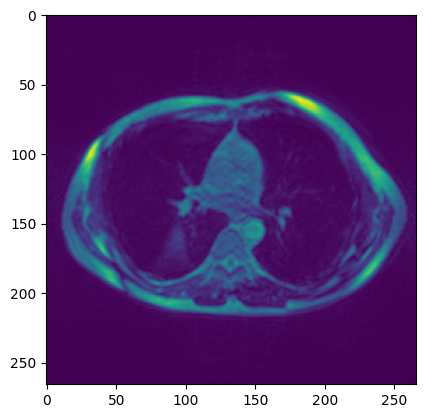

In [ ]:
for i in high_quality_subjects.index:
    case_id = high_quality_subjects.loc[i, 'case_id']
    case_number = high_quality_subjects.loc[i, 'case_number']
    # Identify a sample image for each case
    sample_image_directory = f'train/case{case_number}/{high_quality_subjects.loc[i, 'case_id']}/scans'
    sample_image = os.listdir(sample_image_directory)[0] if os.listdir(sample_image_directory) else None

    # Plot the image
    if sample_image:
        image_path = os.path.join(sample_image_directory, sample_image)
        image_data = io.read_image(image_path)
        plt.imshow(image_data.permute(1, 2, 0))
        plt.title(f'Case {case_number} - {sample_image} - {}')
        plt.show()
        # Here you can add code to visualize the image if needed
    else:
        print(f"No images found for case {case_number}.")

In [56]:
sample_image

'slice_0010_266_266_1.50_1.50.png'

In [25]:
high_quality_subjects.to_csv('high_quality_cases.csv')

In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torchvision import io
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

RuntimeError: Trying to override a python impl for DispatchKey.Meta on operator aten::broadcast_tensors

In [2]:
class RealAndSyntheticImageDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples, synthetic_images_folder_path, real_images_folder_path):
        synthetic_images = os.listdir(synthetic_images_folder_path)
        real_images = os.listdir(real_images_folder_path)

        if len(synthetic_images) < num_samples:
            raise ValueError(f"Not enough synthetic images. Found {len(synthetic_images)}, but requested {num_samples}.")
        
        if len(real_images) < num_samples:
            raise ValueError(f"Not enough real images. Found {len(real_images)}, but requested {num_samples}.")
        
        self.synthetic_images_paths = [os.path.join(synthetic_images_folder_path, img) for img in synthetic_images[:num_samples]]
        self.real_images_paths = [os.path.join(real_images_folder_path, img) for img in real_images[:num_samples]]
        self.labels = [0] * num_samples + [1] * num_samples

        self.num_samples = num_samples
    def __len__(self):
        return self.num_samples
    def __getitem__(self, idx):
        # Return a random 1×266×266 tensor and a random binary label
        print(idx)
        image_path = self.synthetic_images_paths[idx] if idx < self.num_samples else self.real_images_paths[idx - self.num_samples]
        image_data = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        label = self.labels[idx]
        
        return image_data, label, image_path

In [3]:
dataset = RealAndSyntheticImageDataset(
    10, 'singan_output_from_similarity', '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/Input/data-RGBA'
)
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [ ]:
for image, label, image_path in train_loader:
    print(image.shape, label)
    # Here you can add code to visualize the image if needed
    plt.imshow(image[0])
    plt.show()
    # break  # Remove this line to iterate through the entire dataset

5
torch.Size([1, 250, 250]) tensor([0])


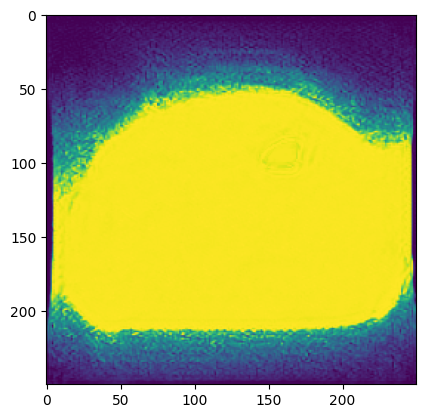

In [ ]:
for image, label, image_path in train_loader:
    print(image.shape, label)
    # Here you can add code to visualize the image if needed
    plt.imshow(image[0])
    plt.title(f'Image Path: {image_path[0]} - Label: {label.item()}')
    plt.show()
    # break  # Remove this line to iterate through the entire dataset

('singan_output_from_similarity/case138_day11_slice_0069_8.png',)

In [21]:
image[0][:3].shape

torch.Size([3, 250, 250])